# Lecture 10 — Radiative Equilibrium & the Temperature Correction

*Stellar Spectroscopy from Scratch — rebuilding the physics of ATLAS and SYNTHE from first principles*

*Yuan-Sen Ting*

*Written in collaboration with **Claude Opus 4.8**, under the author's supervision. Schematics generated with **Gemini 3 Pro** (Nano Banana).*

*Every result in this book is checked against reference values computed with [**pykurucz**](https://arxiv.org/abs/2603.11693) — a pure-Python implementation of Kurucz's ATLAS12 and SYNTHE — shipped beside the lectures as small data files, so the notebooks need only NumPy to run.*

---

**Learning objectives.** By the end of this lecture you will be able to:

- **Measure** the radiative flux as a function of depth in the grey starting atmosphere and see directly that it is *not* constant — so the grey starting model, evaluated with the real non-grey opacity, violates **radiative equilibrium** and its temperature must be corrected.
- Build the **Rosseland mean opacity** $\kappa_{\rm Ross}$ — a *harmonic*, $\partial B_\nu/\partial T$-weighted average over frequency — and the real **Rosseland optical-depth scale** $\tau_{\rm Ross}$ that replaces the grey-start placeholder.
- Compute the per-frequency Eddington flux $H_\nu$ and the moment $(J_\nu-S_\nu)$ with the **JOSH** solver from Lecture 8, and accumulate the four depth integrals the correction needs.
- Assemble the ATLAS temperature correction $T_1 = \Delta T_{\rm flux} + \Delta T_\Lambda + \Delta T_{\rm surf}$ from its three physically distinct pieces — the **Avrett–Krook** flux-constancy term, the **local-$\Lambda$** surface term, and the **surface-boundary** term — and explain what each one fixes.
- Re-integrate hydrostatic equilibrium for the density correction $\Delta\rho x$, take **one converging step**, and reproduce the production code's corrected temperature *and* corrected column mass to the pipeline's **$\sim10^{-9}$ roundoff floor** — with the radiation pressure $P_{\rm rad}$ now *computed* from the per-frequency flux (the `RADIAP` moment), not read.

## Introduction: the half of the atmosphere we still owe

Lecture 9 built the **hydrostatic** half of a model atmosphere: from $T_{\rm eff}$ and $\log g$ it produced a run of temperature, pressure, and column mass that balances the weight of the overlying gas exactly. But it built that structure on two placeholders. The temperature came from the **grey/Hopf law**, which assumes the opacity is the same at every wavelength; and the opacity itself was the crude cold-start value $\kappa\equiv1$. Neither assumption is true of a real star, where the opacity swings over orders of magnitude from one wavelength to the next, and the temperature that the grey law predicts is *not* the temperature that conserves energy.

A note on notation before we start, because one symbol recurs everywhere below. Following ATLAS, `RHOX` (written $\rho x$ in formulas) denotes the **column mass** $m$ in g cm$^{-2}$ — the integrated mass of gas above a layer — *not* the local mass density $\rho$. So the "density correction" $\Delta\rho x$ we build at the end is really a *column-mass* correction; read $\rho x$ as a single bookkeeping variable, the natural depth coordinate for a hydrostatic atmosphere.

The missing constraint is **radiative equilibrium**. In the convection-off model we keep here for a clean first reproduction — a good approximation in the visible photospheric layers of a star like the Sun, though not throughout the solar envelope — essentially all the transported energy flows outward as radiation, and none is created or destroyed locally: nuclear burning is far below, and with convection switched off there is no other channel. Energy conservation then demands that, in this plane-parallel setup, the **radiative flux be the same at every depth** — whatever flux crosses one layer must cross the next. Equivalently, the physical frequency-integrated flux must equal $\sigma T_{\rm eff}^4$ everywhere (so the Eddington flux $H$ must equal $\sigma T_{\rm eff}^4/4\pi$), and its divergence must vanish.

A true grey atmosphere *does* hold constant flux — but only for its own idealized grey opacity. The moment we evaluate the grey starting model's flux with the **actual frequency-dependent continuum opacity**, it no longer satisfies radiative equilibrium. We will *measure* that flux layer by layer and watch it drift with depth — proof that the grey-start temperature is wrong for the real opacity. ATLAS fixes it with a **temperature correction**: at each depth it computes how far the flux is off, works out which way and by how much the temperature must move to push the flux back toward constancy, and applies that shift. Iterating the correction (recomputing opacities and fluxes on the new temperature, correcting again) drives the model to radiative equilibrium. This lecture builds **one step** of that correction engine — Kurucz's `TCORR`, sketched below — and benchmarks it to the pipeline's $\sim10^{-9}$ roundoff floor. It reuses two engines we have already built from scratch: the **JOSH** moment solver (Lecture 8) for the per-frequency flux, and the **continuum opacity** (Lecture 3), which we take as a given input so we can spend our effort on the genuinely new physics: the Rosseland mean and the correction itself.

![The temperature-correction loop: measure the depth-dependent flux, build the Rosseland scale, assemble the three-term correction $T_1$, restore hydrostatic balance, and remap — one ATLAS `TCORR` iteration toward radiative equilibrium.](resources/figures/s9_tcorr.png)

## Setup and the reference

We import only NumPy and Matplotlib. The benchmark target is `reference/tcorr_ref.npz`, produced once by the production code on the solar parameters ($T_{\rm eff}=5770$ K, $\log g=4.44$) in a deliberately clean configuration: **one** ATLAS iteration, **continuum opacity only** (no line blanketing — so no multi-gigabyte line lists are needed), **convection off**, and **serial** execution so the result is bit-reproducible. The file ships:

- the **grey starting model** (`T_in`, `rhox_in`, `p_in`) — the seed from Lecture 9;
- the per-frequency **continuum opacity** on ATLAS's 30000-point frequency grid (`freq_hz`, `rco` quadrature weights, absorption `acont`, scattering `sigmac`, source `scont`) — the Lecture-3 engine's output, treated here as a *given input*;
- the **JOSH tables** (`josh_coefh`) plus the shared `josh_tables.npz` from Lecture 8;
- the reference **accumulators and corrected model** we check against.

We store the continuum arrays as `float32` (JOSH casts its iterate to float32 internally anyway, so nothing is lost relative to the reference calculation used here).

In [1]:
import pathlib
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (7.2, 4.3), "figure.dpi": 120, "savefig.facecolor": "white",
    "axes.grid": True, "grid.alpha": 0.25, "axes.axisbelow": True,
    "font.size": 11, "axes.titlesize": 12.5, "axes.labelsize": 11.5})

REF = np.load(pathlib.Path("..") / "reference" / "tcorr_ref.npz")
JT  = np.load(pathlib.Path("..") / "reference" / "josh_tables.npz")   # Lecture 8 tables

TEFF = float(REF["teff"]); LOGG = float(np.log10(float(REF["gravity_cgs"])))
GRAV = float(REF["gravity_cgs"])
print(f"target: temperature correction for Teff = {TEFF:.0f} K, log g = {LOGG:.2f}")
print(f"reference arrays: {len(REF.files)} total")
print(f"  continuum grid: {REF['freq_hz'].size} frequencies x {REF['T_in'].size} layers")

target: temperature correction for Teff = 5770 K, log g = 4.44
reference arrays: 36 total
  continuum grid: 30000 frequencies x 80 layers


### Constants and the depth grid

We use exactly the constants ATLAS uses (the last digits matter for a bit-level match): the Stefan–Boltzmann constant $\sigma$, Planck's $h$, and Boltzmann's $k$. The grey starting model has $N=80$ layers. We pull out the starting temperature `T`, column mass `rhox`, and gas pressure `p_in`, and form the combination $h/(kT)$ at every layer — call it `hkt` — which becomes the dimensionless $h\nu/(kT)$ only once it is multiplied by a frequency $\nu$ inside the sweep, and which appears throughout the Planck-function and opacity bookkeeping.

One number sets the whole game: the **target flux**. The Eddington flux that must emerge from a star of effective temperature $T_{\rm eff}$ is $H = \sigma T_{\rm eff}^4/(4\pi)$. (ATLAS works with the Eddington flux $H$, the first moment of the intensity; the physical surface flux is $\mathcal F = 4\pi H = \sigma T_{\rm eff}^4$, the familiar Stefan–Boltzmann law.) Radiative equilibrium is the statement that the depth-dependent flux $H(\tau)$ equals this constant $H$ at every layer.

In [2]:
SIGMA  = 5.6697e-5     # Stefan-Boltzmann constant [erg cm^-2 s^-1 K^-4]
PLANCK = 6.6256e-27    # Planck constant h [erg s]
KBOLTZ = 1.38054e-16   # Boltzmann constant k [erg/K]

T    = REF["T_in"].astype(np.float64)      # grey starting temperature [K], 80 layers
rhox = REF["rhox_in"].astype(np.float64)   # column mass RHOX [g/cm^2]
p_in = REF["p_in"].astype(np.float64)      # gas pressure [dyn/cm^2]
n = T.size

# h/(kT) per layer; note this does NOT yet include the frequency nu
hkt = PLANCK / np.maximum(T * KBOLTZ, 1e-300)

# the target: Eddington flux H = sigma Teff^4 / (4 pi).  ATLAS writes 4 pi = 12.5664 explicitly.
flux = SIGMA / 12.5664 * TEFF**4
print(f"target Eddington flux  H = sigma Teff^4 / (4 pi) = {flux:.4e} erg cm^-2 s^-1 sr^-1")
print(f"  (physical surface flux F = 4 pi H = sigma Teff^4 = {SIGMA*TEFF**4:.4e} erg cm^-2 s^-1)")

target Eddington flux  H = sigma Teff^4 / (4 pi) = 5.0009e+09 erg cm^-2 s^-1 sr^-1
  (physical surface flux F = 4 pi H = sigma Teff^4 = 6.2844e+10 erg cm^-2 s^-1)


### A glossary of the main arrays

This lecture juggles many similarly named arrays. For reference, here are the ones that recur, with shape and meaning (all per-layer arrays have length $N=80$; the continuum arrays are $N\times N_\nu$ with $N_\nu=30000$):

| code name | shape | units | meaning |
|---|---|---|---|
| `T`, `rhox`, `p_in` | $N$ | K, g cm$^{-2}$, dyn cm$^{-2}$ | grey-start temperature, column mass, gas pressure |
| `acont`, `sigmac`, `scont` | $N\times N_\nu$ | cm$^2$ g$^{-1}$ (abs/scat), source units | continuum absorption, scattering, source (Lecture 3) |
| `freq`, `rco` | $N_\nu$ | Hz, Hz | frequency grid and its quadrature weights $d\nu$ |
| `abtot`, `alpha` | $N$ | cm$^2$ g$^{-1}$, — | per-frequency total extinction $\kappa_\nu$ and scattering fraction |
| `abross`, `tauros` | $N$ | cm$^2$ g$^{-1}$, — | Rosseland mean opacity and optical depth |
| `flxrad`, `rjmins`, `rdabh`, `rdiagj` | $N$ | ATLAS conventions ($H$-like; opacity-weighted $J-S$; gradient-weighted flux; temperature-response denominator) | the four frequency-integrated correction accumulators |
| `t1`, `tnew` | $N$ | K | the temperature correction $T_1$ and the corrected temperature |

Keep this handy; the meaning of each is spelled out again where it is first built.

## The numerical toolbox (Lecture 8)

Everything below — the optical-depth integrals, the moment derivatives, the remap onto JOSH's fixed grid — is built from the same four Fortran kernels Lecture 8 introduced, so we reproduce them compactly here rather than re-deriving them. Treat them as black boxes with a fixed contract:

- `parcoe(f, x)` — fit smoothly-blended **parabolic coefficients** $a,b,c$ through each triple of points (the helper that `integ` and `deriv` are built on).
- `integ(x, f, start)` — **cumulative integral** $\int f\,dx$ using each interval's parabola; this is how *every* optical depth and *every* flux integral in the lecture is taken.
- `deriv(x, f)` — ATLAS's **cubic-tangent derivative** $df/dx$, used for $dH/d\tau$, opacity gradients, and $dT/d(\rho x)$.
- `map1(xold, fold, xnew)` — **piecewise-quadratic remap** of a quantity from one depth grid to another.

That is all you need to retain. (If any line is unfamiliar, Lecture 8 walks through it; the point of *this* lecture is what we do with these kernels, not the kernels themselves.) We start with the first three, which share the parabola helper.

In [3]:
def parcoe(f, x):
    """Smoothly-blended parabolic coefficients a,b,c so f ~ a + b x + c x^2 (Fortran PARCOE)."""
    nn = f.size; a = np.zeros(nn); b = np.zeros(nn); c = np.zeros(nn)
    if nn == 1: a[0] = f[0]; return a, b, c

    # endpoints: straight lines (no curvature term)
    b[0] = (f[1]-f[0])/(x[1]-x[0]); a[0] = f[0]-x[0]*b[0]
    n1 = nn-1
    b[-1] = (f[-1]-f[n1-1])/(x[-1]-x[n1-1]); a[-1] = f[-1]-x[-1]*b[-1]
    if nn == 2: return a, b, c

    # interior: exact parabola through each (j-1, j, j+1) triple
    for j in range(1, n1):
        j1 = j-1; d = (f[j]-f[j1])/(x[j]-x[j1])
        c[j] = f[j+1]/((x[j+1]-x[j])*(x[j+1]-x[j1])) + (f[j1]/(x[j+1]-x[j1]) - f[j]/(x[j+1]-x[j]))/(x[j]-x[j1])
        b[j] = d - (x[j]+x[j1])*c[j]; a[j] = f[j1] - x[j1]*d + x[j]*x[j1]*c[j]

    # the two near-boundary points use straight segments (ATLAS convention)
    c[1] = 0.0; b[1] = (f[2]-f[1])/(x[2]-x[1]); a[1] = f[1]-x[1]*b[1]
    if nn > 3: c[2] = 0.0; b[2] = (f[3]-f[2])/(x[3]-x[2]); a[2] = f[2]-x[2]*b[2]

    # blend each interior parabola with its neighbour, weighted by curvature
    for j in range(1, n1):
        if c[j] == 0.0: continue
        j1 = min(j+1, nn-1); den = abs(c[j1])+abs(c[j]); wt = abs(c[j1])/den if den > 0 else 0.0
        a[j] = a[j1]+wt*(a[j]-a[j1]); b[j] = b[j1]+wt*(b[j]-b[j1]); c[j] = c[j1]+wt*(c[j]-c[j1])

    # last interior point inherits the endpoint fit
    a[n1-1] = a[-1]; b[n1-1] = b[-1]; c[n1-1] = c[-1]
    return a, b, c

`integ` and `deriv` both ride on those coefficients. We take them one at a time. First `integ`: it analytically integrates each interval's parabola and accumulates the running total — this is the quadrature behind every optical-depth and flux integral in the lecture.

In [4]:
def integ(x, f, start):
    """Cumulative integral of f dx (each interval's parabola), seeded at start (Fortran INTEG)."""
    nn = f.size; out = np.zeros(nn)
    if nn == 0: return out

    # parabola coefficients per interval; seed the running sum at start
    a, b, c = parcoe(f, x); out[0] = start
    for i in range(nn-1):
        dx = x[i+1]-x[i]                             # width of this interval
        # exact integral of (a + b x + c x^2) across [x_i, x_{i+1}], factored for stability
        term = a[i] + 0.5*b[i]*(x[i+1]+x[i]) + (c[i]/3.0)*((x[i+1]+x[i])*x[i+1] + x[i]*x[i])
        out[i+1] = out[i] + term*dx                  # accumulate
    return out

And `deriv`, the cubic-tangent derivative: one-sided slopes at the ends, and at each interior point a curvature-limited combination of the left and right slopes via the tangent addition formula — the same kernel Lecture 8 introduced.

In [5]:
def deriv(x, f):
    """Cubic-tangent derivative df/dx (Fortran DERIV)."""
    nn = f.size; d = np.zeros(nn)
    if nn < 2: return d

    # one-sided slopes at the ends
    d[0] = (f[1]-f[0])/(x[1]-x[0]); d[-1] = (f[-1]-f[-2])/(x[-1]-x[-2])
    if nn == 2: return d

    # sign of the grid direction (the tangent formula needs it)
    s = abs(x[1]-x[0])/(x[1]-x[0]) if x[1] != x[0] else 1.0
    for j in range(1, nn-1):
        # local magnitude, used to normalise the slopes for the tangent limiter
        scale = max(abs(f[j-1]), abs(f[j]), abs(f[j+1]))
        scale = scale/abs(x[j]) if x[j] != 0.0 else scale
        if scale == 0.0: scale = 1.0
        # right/left slopes, then their tangent half-angles
        d1 = (f[j+1]-f[j])/(x[j+1]-x[j])/scale; d0 = (f[j]-f[j-1])/(x[j]-x[j-1])/scale
        t1 = d1/(s*np.sqrt(1.0+d1*d1)+1.0); t0 = d0/(s*np.sqrt(1.0+d0*d0)+1.0)
        # combine via the tangent addition formula (curvature-limited)
        d[j] = (t1+t0)/(1.0-t1*t0)*scale
    return d

The fourth kernel, `map1`, is the one we keep as a single block: it is a Fortran state machine that walks the new grid and the old grid together, so splitting it would break the carried-over interpolation coefficients. The logic is a single sweep — for each target point `xk` it advances a cursor `l` through the source grid until it brackets `xk`, fits a backward and a forward parabola around that bracket (reusing the previous step's forward fit as this step's backward fit when it can), blends the two by curvature weight, and evaluates. The endpoints and the first two intervals fall back to straight lines, exactly as ATLAS does. It returns the remapped array plus the final cursor position. The comments below mark each branch.

In [6]:
def map1(xold, fold, xnew):
    """Piecewise-quadratic remap of fold(xold) onto xnew (Fortran MAP1).  Returns (fnew, ll-1)."""
    nold, nnew = xold.size, xnew.size
    fnew = np.zeros(nnew)
    if nold == 0 or nnew == 0: return fnew, 0
    xo = np.empty(nold+1); fo = np.empty(nold+1); xo[1:] = xold; fo[1:] = fold   # 1-based padding (Fortran indexing)
    l = 2; ll = 0; cfor = bfor = afor = cbac = bbac = abac = a = b = c = 0.0     # cursor + carried parabola coeffs
    for k in range(1, nnew+1):
        xk = xnew[k-1]                                  # the target abscissa we want fold at
        while True:
            if xk < xo[l]:                              # cursor now brackets xk: l-1 <= xk < l
                if l == ll: break                       # same bracket as last point -> reuse a,b,c
                if l == 2 or l == 3:                    # first interval: straight line only
                    l = min(nold, l); c = 0.0
                    b = (fo[l]-fo[l-1])/(xo[l]-xo[l-1]); a = fo[l]-xo[l]*b; ll = l; break
                l1 = l-1
                if l > ll+1 or l == 3 or l == 4:        # build the backward parabola through (l-2, l-1, l)
                    l2 = l-2; d = (fo[l1]-fo[l2])/(xo[l1]-xo[l2])
                    cbac = fo[l]/((xo[l]-xo[l1])*(xo[l]-xo[l2])) + (fo[l2]/(xo[l]-xo[l2]) - fo[l1]/(xo[l]-xo[l1]))/(xo[l1]-xo[l2])
                    bbac = d - (xo[l1]+xo[l2])*cbac; abac = fo[l2] - xo[l2]*d + xo[l1]*xo[l2]*cbac
                else:
                    cbac, bbac, abac = cfor, bfor, afor # else reuse last step's forward fit as this backward fit
                if l >= nold: c, b, a, ll = cbac, bbac, abac, l; break   # no forward neighbour: use backward only
                d = (fo[l]-fo[l1])/(xo[l]-xo[l1])        # build the forward parabola through (l-1, l, l+1)
                cfor = fo[l+1]/((xo[l+1]-xo[l])*(xo[l+1]-xo[l1])) + (fo[l1]/(xo[l+1]-xo[l1]) - fo[l]/(xo[l+1]-xo[l]))/(xo[l]-xo[l1])
                bfor = d - (xo[l]+xo[l1])*cfor; afor = fo[l1] - xo[l1]*d + xo[l]*xo[l1]*cfor
                wt = abs(cfor)/(abs(cfor)+abs(cbac)) if abs(cfor) != 0.0 else 0.0   # curvature-weighted blend
                a = afor+wt*(abac-afor); b = bfor+wt*(bbac-bfor); c = cfor+wt*(cbac-cfor); ll = l; break
            l += 1                                      # xk not yet bracketed: advance the cursor
            if l > nold:                                # ran off the deep end: straight line on the last interval
                l = min(nold, l); c = 0.0
                b = (fo[l]-fo[l-1])/(xo[l]-xo[l-1]); a = fo[l]-xo[l]*b; ll = l; break
        fnew[k-1] = a + (b + c*xk)*xk                   # evaluate the chosen parabola at xk
    return fnew, max(ll-1, 0)

def map1_scalar(xold, fold, xv):
    """Convenience wrapper: remap to a single abscissa and return a Python float."""
    out, _ = map1(np.asarray(xold), np.asarray(fold), np.asarray([xv])); return float(out[0])

## JOSH, for the full depth profile (Lecture 8)

Lecture 8 used JOSH to produce one number per wavelength — the emergent surface flux. The temperature correction needs **more**: at every depth and every frequency it needs the Eddington flux $H_\nu(\tau)$ and the moment $(J_\nu - S_\nu)(\tau)$, the difference between the mean intensity and the source function. So here we run the same JOSH algorithm but read out the *depth profiles*, not just the surface value.

The mechanics are exactly Lecture 8's. Rather than one long block, we break JOSH into four named helpers — one per stage — and a thin `josh_profiles` driver that calls them in order. The four stages are: **(a)** form the per-frequency optics (total extinction $\kappa_\nu$, scattering fraction $\alpha_\nu$, non-scattering emissivity source $\bar S_\nu$, monochromatic optical depth $\tau_\nu$); **(b)** map the source onto JOSH's fixed 51-point $\tau$-grid and run the **float32** $\Lambda$-iteration that solves the scattering problem there — the one place the whole pipeline drops to single precision (Lecture 8 explains why; it is the reason our final benchmark carries a float32 floor); **(c)** solve the thin outer layers directly on the physical grid (JOSH's "label-401" branch, which for this solar continuum always applies near the surface); **(d)** read the deep-layer moments off the grid solution and map them back. The driver returns $\tau_\nu$, $H_\nu$, $(J_\nu - S_\nu)$, $\kappa_\nu$, and $\alpha_\nu$ at every layer — the five profiles the correction consumes.

First the JOSH tables and the two convergence constants, used by every stage below.

In [7]:
XTAU  = JT["xtau"].astype(np.float64)        # JOSH fixed optical-depth grid (51 points)
COEFJ = JT["coefj"].astype(np.float64)       # J-moment operator (51x51), from Lecture 8
COEFH = REF["josh_coefh"].astype(np.float64) # H-moment operator (51x51); shipped here (L8 omits it)
NX = XTAU.size

# precomputed diagonal of the J operator (reused on every Gauss-Seidel sweep)
COEFJ_DIAG = np.diag(COEFJ).astype(np.float32)
ITER_TOL = 1.0e-5                                # relative tolerance for both iterations

### (a) Per-frequency optics

The first stage turns this frequency's continuum opacity and source into the four quantities JOSH works with: the total extinction $\kappa_\nu$ (`abtot`, absorption + scattering, floored away from zero), the scattering fraction $\alpha_\nu=\sigma_\nu/\kappa_\nu$ (`alpha`), the non-scattering emissivity source $\bar S_\nu$ (`snubar`, the thermal source used in the source-function split $S_\nu=(1-\alpha)\bar S_\nu+\alpha J_\nu$, with scattering added separately through the $\alpha J_\nu$ term — note that with no line absorption the denominator is just `acont`), and the monochromatic optical depth $\tau_\nu=\int\kappa_\nu\,d(\rho x)$ (`taunu`).

In [8]:
def josh_optics(acont, scont, sigmac, rhox, bnu):
    """Stage (a): per-frequency optics. Returns kappa_nu, alpha_nu, Sbar_nu, tau_nu."""
    abtot = np.maximum(acont + sigmac, 1e-300)          # total extinction kappa_nu
    alpha = sigmac / abtot                               # scattering fraction sigma/kappa
    den   = acont                                        # (no line absorption in continuum-only)
    snubar = bnu.copy()
    np.divide(acont*scont, den, out=snubar, where=den > 0.0)   # thermal+scattering source Sbar_nu
    taunu = integ(rhox, abtot, abtot[0]*rhox[0])         # monochromatic optical depth tau_nu
    return abtot, alpha, snubar, taunu

### (b) The float32 $\Lambda$-iteration on the JOSH grid

Stage (b) has two parts: a *setup* that remaps the source and scattering fraction onto JOSH's fixed 51-point $\tau$-grid, and the tight **float32** $\Lambda$-iteration itself. We keep them as two helpers — the setup is pure preparation, the iteration is an irreducible single-precision kernel.

The setup `josh_grid_setup` maps $\bar S_\nu$ and $\alpha_\nu$ from the physical $\tau_\nu$ grid onto `XTAU`, casts both to **float32**, clamps them to physical ranges, and flat-extrapolates any grid points that sit above the physical surface ($\tau<\tau_\nu[0]$). It returns the float32 source `xsbar8`, the float32 scattering fraction `xalpha8`, and `maxj`, the index of the deepest grid point still inside the physical atmosphere.

In [9]:
def josh_grid_setup(snubar, alpha, taunu):
    """Stage (b) setup: remap Sbar and alpha onto the float32 JOSH grid, clamp, extrapolate.
    Returns (xsbar8, xalpha8, maxj), all on XTAU; the float32 arrays seed the Lambda-iteration."""
    # remap source and scattering fraction onto the fixed JOSH tau-grid
    xsbar8, maxj = map1(taunu, snubar, XTAU)
    xalpha8, maxj = map1(taunu, alpha, XTAU)

    # cast to float32 and clamp to physical ranges
    xalpha8 = np.maximum(xalpha8.astype(np.float32), np.float32(0.0))
    xsbar8  = np.maximum(xsbar8.astype(np.float32),  np.float32(1.0e-38))

    # grid points above the physical surface: extrapolate flat from the top layer
    mask = XTAU < taunu[0]
    if np.any(mask):
        xsbar8[mask] = max(snubar[0], 1.0e-38); xalpha8[mask] = max(alpha[0], 0.0)
    return xsbar8, xalpha8, maxj

Now the kernel itself — the one place the whole pipeline runs in single precision. We **keep it whole** (splitting it would change the float32 operation order) and walk through it step by step instead.

It solves $(I-\alpha\Lambda)S = (1-\alpha)\bar S$ for the source `xs` on the JOSH grid by **backward Gauss–Seidel**, every operation in `float32` (Fortran `REAL*4`). Reading the body:

1. **Initial guess and precomputed pieces.** The iterate `xs` starts at the thermal source `xsbar8`. We precompute `diag` $=1-\alpha\,\Lambda_{kk}$ (the diagonal of the operator $I-\alpha\Lambda$) and `xsbar_mod` $=(1-\alpha)\bar S$ (the right-hand side) once, since neither changes across sweeps.
2. **Outer loop = one full sweep.** Each pass sets a convergence flag `iferr=0` and walks the grid.
3. **Inner loop, deep → shallow.** The index `k = NX-1-kk` runs the sweep *upward* from the deepest grid point. For each `k`: form $(\Lambda\,xs)_k$ as a float32 dot product (`dot`); build the residual `num` $=\alpha_k\,(\Lambda xs)_k + (1-\alpha)\bar S_k - xs_k$; divide by the diagonal `dd` (guarded away from zero) to get the Gauss–Seidel update `delxs`.
4. **Convergence test.** If the *relative* update `|delxs/xb|` exceeds the tolerance at any layer (with `xb` the current value, guarded from zero), set `iferr=1` — this sweep has not converged.
5. **Apply, keep positive.** Update `xs[k] = max(xs[k]+delxs, 1e-37)`, immediately so the next (shallower) `k` sees it — that immediacy is what makes it Gauss–Seidel rather than Jacobi.
6. **Stop.** When a whole sweep passes with `iferr==0`, every layer is below tolerance and we break.

The function returns the converged float32 source `xs`.

In [10]:
def josh_lambda_iteration(xsbar8, xalpha8):
    """Stage (b) kernel: backward Gauss-Seidel solve of (I - alpha Lambda) S = (1-alpha) Sbar,
    every operation in float32 (Fortran REAL*4) -- KEPT WHOLE (the precision floor lives here)."""
    xs = np.zeros(NX, dtype=np.float32)                  # the source iterate, on the JOSH grid (REAL*4)
    xs[:] = xsbar8                                       # initial guess: thermal source
    diag = np.float32(1.0) - xalpha8*COEFJ_DIAG          # diagonal of (I - alpha*Lambda)
    xsbar_mod = (np.float32(1.0) - xalpha8)*xsbar8        # thermal part of the source equation

    for _ in range(NX):                                  # backward Gauss-Seidel sweep, REAL*4
        iferr = 0
        for kk in range(NX):
            k = NX-1-kk                                  # sweep from the deep grid upward
            dot = np.float32(np.dot(COEFJ[k, :].astype(np.float32), xs))   # (Lambda xs)_k
            num = np.float32(dot*xalpha8[k] + xsbar_mod[k] - xs[k])        # residual at k
            dd = np.float32(diag[k])
            if abs(float(dd)) < 1.0e-37: dd = np.float32(1.0e-37 if float(dd) >= 0.0 else -1.0e-37)  # guard /0
            delxs = np.float32(num/dd)                   # Gauss-Seidel update
            xb = np.float32(xs[k])
            if abs(float(xb)) < 1.0e-37: xb = np.float32(1.0e-37 if float(xb) >= 0.0 else -1.0e-37)
            if np.float32(abs(float(delxs/xb))) > np.float32(ITER_TOL): iferr = 1   # not yet converged here
            xs[k] = np.float32(max(float(np.float32(xs[k] + delxs)), 1.0e-37))      # apply, keep positive
        if iferr == 0: break                             # every layer below tolerance -> done
    return xs

### (c) The optically-thin outer layers

Stage (c) is JOSH's "label-401" branch: the thin outer layers are solved by a short fixed-point iteration *directly on the physical $\tau_\nu$ grid*, because the diffusion-style moments are unreliable where there is little material above. Working back from the grid solution it sets the deep layers' source to thermal, then repeatedly: guards against negative source/flux (falling back to the Planck source if either goes non-physical), forms $H=\tfrac13\,dS/d\tau$ (the Eddington flux) and $(J-S)=dH/d\tau$ by `deriv`, rebuilds $J$, and updates each layer's source as $(1-\alpha)\bar S+\alpha J$ until it converges. It mutates the working arrays `snu`, `hnu`, `jnu`, `jmins`, `snubar` in place.

In [11]:
def josh_thin_layers(maxj, alpha, snubar, bnu, taunu, snu, hnu, jnu, jmins):
    """Stage (c): fixed-point solve of the optically-thin outer layers on the physical grid
    (JOSH label-401). Mutates snu/hnu/jnu/jmins/snubar in place; returns nothing."""
    maxj1 = maxj+1 if maxj != 1 else 1

    # deep layers: source = thermal (the iteration below refines the rest)
    snu[maxj1-1:] = snubar[maxj1-1:]
    m0 = max(maxj-1, 1) - 1; nmj0 = maxj-1

    for _ in range(NX):
        error = 0.0; ifneg = 0

        # negativity guard: if the source went non-physical, fall back to the Planck source
        if np.any(snu[m0:] <= 0.0): ifneg = 1; snubar[m0:] = bnu[m0:]; snu[m0:] = bnu[m0:]

        # H = (1/3) dS/dtau (Eddington flux); it must stay outward-positive
        hnu[m0:] = deriv(taunu[m0:], snu[m0:]) / 3.0
        if np.any(hnu[m0:] <= 0.0):
            ifneg = 1; snubar[m0:] = bnu[m0:]; snu[m0:] = bnu[m0:]
            hnu[m0:] = deriv(taunu[m0:], snu[m0:]) / 3.0

        # (J - S) = dH/dtau
        jmins[nmj0:] = deriv(taunu[nmj0:], hnu[nmj0:])

        # rebuild J and update each layer's source as (1-alpha)Sbar + alpha J
        for j in range(maxj1-1, n):
            if ifneg == 1: jmins[j] = 0.0
            jnu[j] = jmins[j] + snu[j]
            snew = (1.0-alpha[j])*snubar[j] + alpha[j]*jnu[j]
            error += abs(snew - snu[j]) / max(abs(snew), 1e-300); snu[j] = snew
        if error < ITER_TOL: break

### (d) The deep-layer moments, and the driver

Stage (d) reads the deep-layer moments straight off the converged grid solution `xs`: $(J-S)$ is $(-I+\Lambda)\,xs$ (the `COEFJ` operator minus identity) and $H$ is the `COEFH` operator applied to `xs`, both then remapped from the JOSH grid onto the physical layers above `maxj`. Finally `josh_profiles` is the thin driver that allocates the working arrays, calls stages (a)–(d) in order at exactly the points the original single block did, and returns the five profiles.

In [12]:
def josh_deep_moments(xs, maxj, taunu, hnu, jmins):
    """Stage (d): moments straight from the grid solution, mapped back onto the physical layers.
    Mutates hnu/jmins[:maxj] in place; returns nothing."""
    xjs = (-xs + COEFJ.astype(np.float32) @ xs).astype(np.float64)   # (J - S) on the JOSH grid
    xh  = (COEFH @ xs).astype(np.float64)                            # H on the JOSH grid
    jmins[:maxj], _ = map1(XTAU, xjs, taunu[:maxj])                  # remap onto physical layers
    hnu[:maxj], _   = map1(XTAU, xh,  taunu[:maxj])

def josh_profiles(acont, scont, sigmac, rhox, bnu):
    """JOSH depth profiles for one continuum frequency (ifscat=1, line opacity off).
    Returns taunu, H_nu, (J_nu - S_nu), kappa_nu (=abtot), alpha_nu, all at every layer."""
    abtot, alpha, snubar, taunu = josh_optics(acont, scont, sigmac, rhox, bnu)   # (a)
    snu = np.zeros(n); hnu = np.zeros(n); jnu = np.zeros(n); jmins = np.zeros(n)

    xsbar8, xalpha8, maxj = josh_grid_setup(snubar, alpha, taunu)                # (b) setup
    xs = josh_lambda_iteration(xsbar8, xalpha8)                                  # (b) float32 kernel

    # the converged grid source, mapped back onto the physical layers
    snu_head, _ = map1(XTAU, xs.astype(np.float64), taunu[:maxj]); snu[:maxj] = snu_head
    josh_thin_layers(maxj, alpha, snubar, bnu, taunu, snu, hnu, jnu, jmins)      # (c)
    josh_deep_moments(xs, maxj, taunu, hnu, jmins)                              # (d)
    return taunu, hnu, jmins, abtot, alpha

## Sweeping the spectrum: the Rosseland mean and the flux integrals

We now sweep all 30000 continuum frequencies. At each one we build the Planck function $B_\nu(T)$ and the stimulated-emission factor, run JOSH for the depth profiles, and accumulate **five** depth integrals over frequency. Four of them feed the temperature correction; the fifth is the Rosseland mean.

**The Rosseland mean opacity** is the single most important new quantity. To compress a wildly wavelength-dependent opacity into one number per layer for the optical-depth scale, ATLAS uses the *Rosseland mean* — a **harmonic** average of $\kappa_\nu$ weighted by $\partial B_\nu/\partial T$ (the weighting that appears in the diffusion-limit flux, not the actual computed flux $H_\nu$):

$$
\frac{1}{\kappa_{\rm Ross}} = \frac{\displaystyle\int_0^\infty \frac{1}{\kappa_\nu}\,\frac{\partial B_\nu}{\partial T}\,d\nu}{\displaystyle\int_0^\infty \frac{\partial B_\nu}{\partial T}\,d\nu},
\qquad
\int_0^\infty\frac{\partial B_\nu}{\partial T}\,d\nu = \frac{4\sigma}{\pi}T^3 .
$$

The harmonic (reciprocal) weighting is not a convention — it is what falls out of the diffusion limit deep in the star, where the flux is set by *how easily* radiation leaks through, so the *transparent* windows dominate. A simple average would be swamped by the opaque lines; the harmonic mean correctly lets the low-opacity windows carry the flux. In code we accumulate the integral $\int \frac{1}{\kappa_\nu}\frac{\partial B_\nu}{\partial T}\,d\nu$ frequency by frequency (note the $1/\kappa_\nu$); it sits in the *numerator* of the equation above, and becomes the **denominator** when we invert to solve for $\kappa_{\rm Ross} = \frac{4\sigma}{\pi}T^3 / (\text{accumulator})$. The frequency integral is done with the quadrature weights `rco` that ship with the grid (the spacing-aware $d\nu$).

In [13]:
freq   = REF["freq_hz"].astype(np.float64)   # 30000 continuum frequencies [Hz]
rco    = REF["rco"].astype(np.float64)       # frequency quadrature weights (d_nu)
acont  = REF["acont"].astype(np.float64)     # continuum absorption [per layer, per freq] (Lecture 3)
sigmac = REF["sigmac"].astype(np.float64)    # continuum scattering
scont  = REF["scont"].astype(np.float64)     # continuum source function
nf = freq.size

We accumulate **six** depth profiles as we sweep frequency. The Rosseland accumulator (`ross_acc`) becomes the optical-depth scale; four of the rest (`flxrad`, `rjmins`, `rdabh`, `rdiagj`) feed the temperature correction; and the last, `accrad`, is the **radiation-pressure moment** ATLAS calls `RADIAP`. We allocate them all as zeros and add each frequency's weighted contribution inside the loop.

**The radiation-pressure moment.** Photons carry momentum, so the radiation field exerts a pressure on the gas. The hydrostatic integrator solves for the *total* pressure; the radiation-pressure contribution, measured relative to the surface boundary value, is then removed to recover the *gas* pressure (the pressure that sets the equation of state). The momentum the radiation transfers per unit mass per unit time is the **radiative acceleration** — the frequency integral of the opacity times the flux,
$$
g_{\rm rad}(\rho x) \;=\; \frac{4\pi}{c}\int_0^\infty \kappa_\nu\, H_\nu \, d\nu ,
$$
(reusing the same per-frequency opacity $\kappa_\nu$ and flux $H_\nu$ profiles that JOSH already supplies for the Rosseland and flux integrals — read the dimensions: $\kappa_\nu$ [cm$^2$ g$^{-1}$] times $H_\nu$ [erg cm$^{-2}$ s$^{-1}$ Hz$^{-1}$ sr$^{-1}$] times $4\pi/c$ gives an acceleration per gram). Integrating that acceleration down the column mass gives the **radiation pressure** itself,
$$
P_{\rm rad}(\rho x) \;=\; \int_0^{\rho x} g_{\rm rad}\, d(\rho x') ,
$$
the depth profile the density correction needs. So we accumulate the *integrand* $\kappa_\nu H_\nu$ frequency by frequency into `accrad` here (one extra line in the loop, reusing the $\kappa_\nu$ and $H_\nu$ JOSH already gives us), and finish the two factors — the $4\pi/c$ and the column-mass integral — right after the sweep, exactly as ATLAS's `RADIAP` does. This closes the last radiative moment: the radiation pressure is now *computed* from the per-frequency flux, not read from a table.

In [14]:
# six accumulators, all functions of depth:

# Rosseland integral int (1/kappa) dB/dT d_nu  (becomes the denominator)
ross_acc = np.zeros(n)

# int H_nu d_nu -> the radiative flux at each depth
flxrad   = np.zeros(n)

# int kappa (J-S) d_nu -> the net radiative heating
rjmins   = np.zeros(n)

# int (d kappa/d rhox)/kappa * H_nu d_nu  (opacity-gradient term)
rdabh    = np.zeros(n)

# diagonal of the Lambda operator (how T responds to its own change)
rdiagj   = np.zeros(n)

# int kappa_nu H_nu d_nu -> the RADIAP radiation-pressure-moment integrand
accrad   = np.zeros(n)

print(f"sweeping {nf} continuum frequencies x {n} layers ... (this is the bulk of the work)")

sweeping 30000 continuum frequencies x 80 layers ... (this is the bulk of the work)


### What the four correction integrals mean

Before we run the loop, here is what each correction integral is for — the physics is easier to follow now than buried in code.

- **`flxrad` $=\int H_\nu\,d\nu$** is simply the **total radiative flux** at each depth. Radiative equilibrium says this should equal the constant target $H$; the whole correction exists to make it so.
- **`rjmins` $=\int \kappa_\nu (J_\nu - S_\nu)\,d\nu$** is the ATLAS heating residual, **proportional to the net radiative heating rate** (constant angular factors like $4\pi$ are absorbed into the code's flux convention, so do not read its absolute value as erg s$^{-1}$ cm$^{-3}$). Where the gas absorbs more than it emits ($J_\nu>S_\nu$, mean intensity exceeds source), it is being heated; the integral measures that imbalance and is the surface diagnostic for the local correction.
- **`rdabh`** carries the **opacity gradient** $\frac{d\kappa_\nu/d(\rho x)}{\kappa_\nu}$ weighted by the flux: it tells the flux-correction term how the optical-depth scale itself shifts when the structure moves.
- **`rdiagj`** is built from the **diagonal of the $\Lambda$ operator** — it measures how strongly the *net heating rate* $\kappa_\nu(J_\nu - S_\nu)$ at a layer responds to a change in that same layer's temperature (so it carries the diagonal of $\Lambda - I$, not of $\Lambda$ alone). It is built from the third exponential integral $E_3$ of the local optical-depth step, and it is the denominator of the local-$\Lambda$ correction below — which divides the *heating residual* `rjmins`, not the flux error, by this response to find the temperature change that would cancel the local heating.

We need one special function, $E_3$. The exponential integral $E_3(\tau)=\int_1^\infty t^{-3}e^{-\tau t}\,dt$ is the angular attenuation kernel that appears when averaging a layer's self-coupling through an optical-depth step in plane-parallel geometry. ATLAS evaluates it with the same rational-polynomial approximation Kurucz used; we reproduce it (with the $E_3 = (e^{-x}-x E_2)$ recurrence applied twice from $E_1$).

In [15]:
def expi3(x):
    """Third exponential integral E_3(x) via Kurucz's rational approximation (Fortran EXPI(3,x))."""
    # Kurucz's fitted rational-polynomial coefficients for E_1, in three argument ranges:
    a = (-44178.5471728217, 57721.7247139444, 9938.31388962037, 1842.11088668, 101.093806161906, 5.03416184097568)
    b = (76537.3323337614, 32597.1881290275, 6106.10794245759, 635.419418378382, 37.2298352833327)
    c = (4.65627107975096e-7, 0.999979577051595, 9.04161556946329, 24.3784088791317, 23.0192559391333, 6.90522522784444, 0.430967839469389)
    dd = (10.0411643829054, 32.4264210695138, 41.2807841891424, 20.4494785013794, 3.31909213593302, 0.103400130404874)
    e = (-0.999999999998447, -26.6271060431811, -241.055827097015, -895.927957772937, -1298.85688746484, -545.374158883133, -5.66575206533869)
    fc = (28.6271060422192, 292.310039388533, 1332.78537748257, 2777.61949509163, 2404.01713225909, 631.6574832808)

    # evaluate E_1(x) on the right rational branch for the argument range
    if x <= 0.0:
        ex1 = 0.0                          # E_1(0) handled by the recurrence below
    else:
        ex = np.exp(-x)
        if x > 4.0:                        # large x: asymptotic rational form for E_1
            ex1 = (ex + ex*(e[0]+(e[1]+(e[2]+(e[3]+(e[4]+(e[5]+e[6]/x)/x)/x)/x)/x)/x)
                   / (x+fc[0]+(fc[1]+(fc[2]+(fc[3]+(fc[4]+fc[5]/x)/x)/x)/x)/x)) / x
        elif x > 1.0:                      # intermediate x
            ex1 = ex*(c[6]+(c[5]+(c[4]+(c[3]+(c[2]+(c[1]+c[0]*x)*x)*x)*x)*x)*x) / (dd[5]+(dd[4]+(dd[3]+(dd[2]+(dd[1]+(dd[0]+x)*x)*x)*x)*x)*x)
        else:                              # small x: rational fit minus the log singularity
            ex1 = (a[0]+(a[1]+(a[2]+(a[3]+(a[4]+a[5]*x)*x)*x)*x)*x) / (b[0]+(b[1]+(b[2]+(b[3]+(b[4]+x)*x)*x)*x)*x) - np.log(x)

    # climb E_1 -> E_2 -> E_3 via the recurrence E_{n+1} = (e^-x - x E_n)/n
    out = ex1
    for i in range(1, 3):
        out = (np.exp(-x) - x*out) / float(i)
    return out

### The $\Lambda$-diagonal accumulator

Before the sweep itself, we pull the most intricate piece — the per-frequency `rdiagj` accumulation — into its own helper. It is a tight numerical loop that walks the layers building the running diagonal `diagj` from the optical-depth step `d` between adjacent layers: small steps ($d\le0.01$) use a series expansion of the $E_3$ contribution to avoid cancellation, larger steps the direct `expi3` evaluation. Each layer's value is then scaled by $\kappa_\nu$, the scattering correction $1/(1-\alpha\,\text{diagj})$, the $(1-\alpha)$ factor, and $\partial B_\nu/\partial T$ at that layer, and added into `rdiagj` with the quadrature weight $w$. Because `diagj` carries forward from one layer to the next, this loop is irreducible — we lift it out whole (same statements, same order) and mutate `rdiagj` in place.

In [16]:
def accumulate_rdiagj(rdiagj, taunu, bnu, hkt, T, stim, abtot, alpha, f, w, n):
    """Add one frequency's E_3-based Lambda-diagonal contribution into rdiagj (in place).
    Tight numerical loop: diagj carries forward layer to layer, so it is kept whole."""
    term2 = 0.0
    for j in range(n):
        term1 = term2                                                # carry the previous layer's half-step term

        # optical-depth step to the next layer
        d = 1e-10 if j == n-1 else (taunu[j+1] - taunu[j]); d = max(1e-10, float(d))
        if d <= 0.01:
            # tiny step: series expansion of the E_3 contribution (avoids cancellation)
            term2 = (0.922784335098467 - np.log(d))*d/4.0 + d*d/12.0 - d**3/96.0 + d**4/720.0
        else:
            ex = expi3(d) if d < 10.0 else 0.0                       # direct E_3 (negligible past d=10)
            term2 = 0.5*(d + ex - 0.5)/d

        diagj = term1 + term2                                        # the local Lambda-operator diagonal value
        dbdtj = bnu[j]*f*hkt[j] / max(T[j]*stim[j], 1e-300)          # dB/dT at this layer
        # scale by kappa, the scattering correction, and dB/dT; accumulate with weight w
        rdiagj[j] += abtot[j]*(diagj-1.0)/max(1.0-alpha[j]*diagj, 1e-300)*(1.0-alpha[j])*dbdtj*w

### The sweep

Now the loop. For each frequency we build $B_\nu$ and $\partial B_\nu/\partial T$ (the latter being $\partial B_\nu/\partial T = B_\nu\,[h\nu/(kT)]\,/\,[T(1-e^{-h\nu/kT})]$ — note the explicit extra $1/T$, which the code carries), call JOSH, and add this frequency's contribution into the five accumulators with the quadrature weight `rco`. The Rosseland accumulator gets $\frac{1}{\kappa_\nu}\frac{\partial B_\nu}{\partial T}$; the flux gets $H_\nu$; the heating gets $\kappa_\nu(J_\nu - S_\nu)$; the opacity-gradient term gets $\frac{1}{\kappa_\nu}\frac{d\kappa_\nu}{d(\rho x)}H_\nu$; and `rdiagj` gets the $E_3$-based $\Lambda$-diagonal, accumulated by the `accumulate_rdiagj` helper just defined. This is the heavy lift of the lecture; on 30000 frequencies it takes a couple of minutes.

In [17]:
for inu in range(nf):
    # this frequency and its quadrature weight d_nu
    f = float(freq[inu]); w = float(rco[inu])

    # e^{-hv/kT} and the stimulated-emission factor
    ehvkt = np.exp(-f*hkt); stim = np.maximum(1.0 - ehvkt, 1e-300)

    # Planck function B_nu(T) (ATLAS constant)
    bnu = 1.47439e-2 * ((f/1e15)**3) * ehvkt / stim

    # this frequency's continuum opacity/source
    ac = acont[:, inu]; sc = sigmac[:, inu]; so = scont[:, inu]

    # JOSH depth profiles, with the ATLAS safety clamp on the flux
    taunu, hnu, jmins, abtot, alpha = josh_profiles(ac, so, sc, rhox, bnu)
    if np.any(hnu < 0.0): hnu = np.maximum(hnu, 1e-99)

    # dB_nu/dT, with the explicit 1/T factor (= B_nu * hv/kT / [T (1-e^{-hv/kT})])
    dbdt = bnu * f * hkt / np.maximum(T*stim, 1e-300)

    # add this frequency's weighted contribution into the five integral accumulators
    ross_acc += dbdt / np.maximum(abtot, 1e-300) * w                       # (1/kappa) dB/dT
    rdabh    += deriv(rhox, abtot) / np.maximum(abtot, 1e-300) * hnu * w   # (dkappa/d rhox)/kappa * H_nu
    rjmins   += abtot * jmins * w                                          # kappa (J-S): net heating
    flxrad   += hnu * w                                                    # H_nu: the radiative flux
    accrad   += abtot * hnu * w                                            # kappa_nu H_nu: RADIAP moment

    # the Lambda diagonal: running E_3-based contribution, layer by layer (in place)
    accumulate_rdiagj(rdiagj, taunu, bnu, hkt, T, stim, abtot, alpha, f, w, n)
print("frequency sweep complete.")

frequency sweep complete.


## The Rosseland optical-depth scale

With the harmonic accumulator in hand, the Rosseland opacity is $\kappa_{\rm Ross} = \frac{4\sigma}{\pi}T^3 \big/ \int \frac{1}{\kappa_\nu}\frac{\partial B_\nu}{\partial T}\,d\nu$, and the **Rosseland optical depth** follows by integrating $\kappa_{\rm Ross}$ against the column mass, $\tau_{\rm Ross}(\rho x) = \int_0^{\rho x}\kappa_{\rm Ross}\,d(\rho x')$, seeded at the top with $\kappa_{\rm Ross}(0)\,\rho x(0)$. This is the *real* optical-depth scale — the placeholder $\kappa\equiv1$ of the grey cold start is finally replaced by an opacity computed from the actual continuum. The correction below works on this $\tau_{\rm Ross}$ grid.

In [18]:
abross = (4.0*SIGMA/3.14159) * T**3 / np.maximum(ross_acc, 1e-300)   # kappa_Rosseland [cm^2/g]
tauros = integ(rhox, abross, abross[0]*rhox[0])                       # Rosseland optical depth

def rel(name, got, refk):
    g = np.asarray(got, float); r = np.asarray(REF[refk], float)
    m = np.abs(r) > 0; e = np.zeros_like(r); e[m] = np.abs(g[m]-r[m])/np.abs(r[m])
    print(f"  {name:26s} max|rel| = {e.max():.2e}   median = {np.median(e):.2e}")
    return e.max()

print("Rosseland mean + tau scale vs reference:")
rel("kappa_Rosseland", abross, "abross_ref")
rel("tau_Rosseland",   tauros, "tauros_ref")
print("\nfrequency-integrated accumulators vs reference:")
rel("flxrad (flux)",   flxrad, "flxrad_ref")
rel("rjmins (heating)", rjmins, "rjmins_ref")
rel("rdabh",           rdabh,  "rdabh_ref")
rel("rdiagj (Lambda diag)", rdiagj, "rdiagj_ref")

Rosseland mean + tau scale vs reference:
  kappa_Rosseland            max|rel| = 8.10e-10   median = 1.61e-10
  tau_Rosseland              max|rel| = 3.18e-10   median = 6.47e-11

frequency-integrated accumulators vs reference:
  flxrad (flux)              max|rel| = 1.31e-07   median = 8.13e-10
  rjmins (heating)           max|rel| = 8.21e-06   median = 7.36e-08
  rdabh                      max|rel| = 1.29e-07   median = 2.05e-09
  rdiagj (Lambda diag)       max|rel| = 9.32e-10   median = 1.82e-10


np.float64(9.315241711656624e-10)

## Finishing the radiation-pressure moment

With the $\kappa_\nu H_\nu$ integrand accumulated in `accrad`, two factors close the **`RADIAP`** moment. First the constant $4\pi/c$ turns the integrated $\int\kappa_\nu H_\nu\,d\nu$ into the radiative acceleration $g_{\rm rad}$ (ATLAS writes $4\pi=12.5664$ and $c=2.99792458\times10^{10}$ cm s$^{-1}$ explicitly, so the last digits match). Then a small numerical safeguard: in the surface layers the depth-resolved flux $H(\tau)$ that JOSH returns can momentarily exceed the target $H$ — an artifact of the not-yet-converged temperature — and letting that non-equilibrium flux overshoot would drive an overly large hydrostatic correction. So where the accumulated flux exceeds the target, ATLAS **caps** the acceleration by the same factor $H/H(\tau)$, holding the radiative push to at most what the target flux can deliver. Finally the capped acceleration is integrated down the column mass (`integ` against `rhox`, seeded at the top) to give the radiation-pressure profile $P_{\rm rad}(\rho x)$.

This is the depth profile the hydrostatic density correction below subtracts to recover the gas pressure. It used to be read straight from the reference; here it is **computed** from the per-frequency flux we just swept — the last radiative moment to be closed.

In [19]:
# (1) the 4 pi / c factor: integrand int kappa_nu H_nu d_nu  ->  radiative acceleration g_rad
conv = 12.5664 / 2.99792458e10     # 4 pi / c
accrad *= conv

# (2) flux-limit safeguard: cap the acceleration where H(tau) overshoots the target H

# depth-resolved flux relative to target; surface layers where the flux runs hot
ratio = flxrad / max(flux, 1e-300)
over  = ratio > 1.0

# hold g_rad to what the target flux delivers
accrad[over] *= flux / np.maximum(flxrad[over], 1e-300)

# (3) integrate the acceleration down the column mass -> the radiation pressure P_rad(rhox);
#     this lives on the Rosseland tau grid -- exactly the grid the density correction consumes
prad = integ(rhox, accrad, accrad[0]*rhox[0])

# prad-vs-reference check.  The reference PRAD ships on the STANDARD tau grid (the production
# code remaps it there for output), so we remap our tauros-grid prad the same way and compare.

# the standard optical-depth grid, then our P_rad mapped onto the reference grid
taustd_chk = 10.0**(-6.875 + np.arange(n)*0.125)
prad_std, _ = map1(tauros, prad, taustd_chk)
rel("prad (radiation pressure)", prad_std, "prad_ref")
print(f"radiation pressure: surface P_rad = {prad[0]:.3e}   deep P_rad = {prad[-1]:.3e} dyn/cm^2")

  prad (radiation pressure)  max|rel| = 4.23e-08   median = 9.25e-10
radiation pressure: surface P_rad = 1.892e-09   deep P_rad = 1.654e+03 dyn/cm^2


## The grey atmosphere is not in radiative equilibrium

Now the central diagnostic. We have the radiative flux `flxrad` $=\int H_\nu\,d\nu$ at every depth. If the grey atmosphere were in radiative equilibrium, this would be a flat line at the target $H = \sigma T_{\rm eff}^4/(4\pi)$. It is not. The plot below shows the **flux error** — the fractional deviation of the depth-dependent flux from the target — across the photosphere. It is off by tens of percent in the surface layers and drifts systematically with depth. That drift is the signature of a temperature that is in the wrong place: too hot here, too cool there, so that energy is being spuriously absorbed at some depths and emitted at others. The temperature correction reads this curve and pushes the temperature to flatten it.

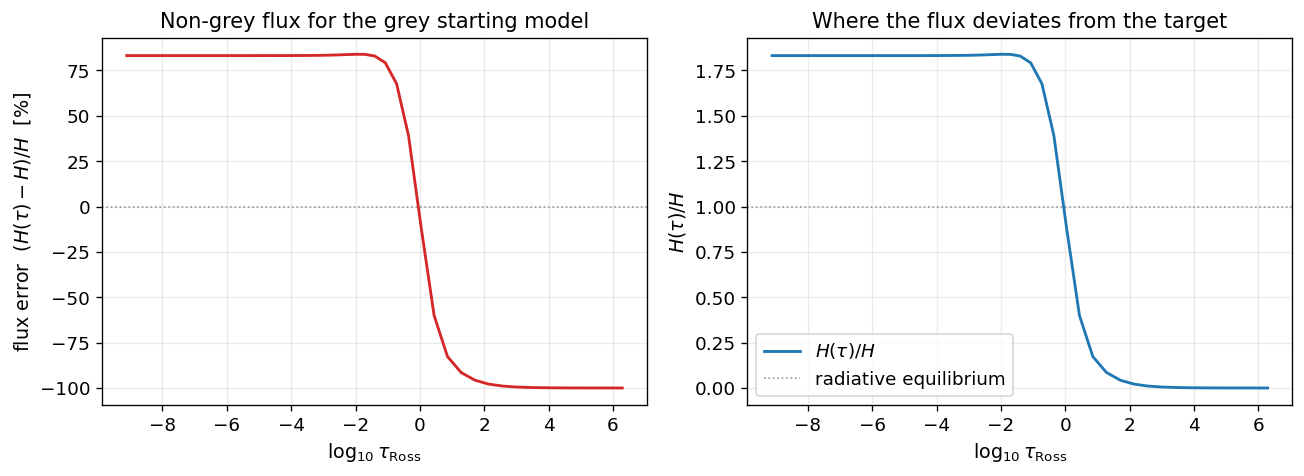

flux error: surface = +83.1%   max |error| = 100.0%   deep (tau~1) = -11.15%


In [20]:
flxerr = (flxrad - flux) / flux * 100.0      # percent flux error at each depth

fig, ax = plt.subplots(1, 2, figsize=(11, 4.1))
ax[0].axhline(0.0, color="0.6", ls=":", lw=1.0)
ax[0].plot(np.log10(tauros), flxerr, color="C3", lw=1.7)
ax[0].set_xlabel(r"$\log_{10}\tau_{\rm Ross}$"); ax[0].set_ylabel(r"flux error  $(H(\tau)-H)/H$  [%]")
ax[0].set_title("Non-grey flux for the grey starting model")

ax[1].plot(np.log10(tauros), flxrad/flux, color="C0", lw=1.7, label=r"$H(\tau)/H$")
ax[1].axhline(1.0, color="0.6", ls=":", lw=1.0, label="radiative equilibrium")
ax[1].set_xlabel(r"$\log_{10}\tau_{\rm Ross}$"); ax[1].set_ylabel(r"$H(\tau)/H$")
ax[1].set_title("Where the flux deviates from the target"); ax[1].legend(loc="best")
fig.tight_layout(); plt.show()
print(f"flux error: surface = {flxerr[0]:+.1f}%   max |error| = {np.abs(flxerr).max():.1f}%   "
      f"deep (tau~1) = {flxerr[np.argmin(np.abs(tauros-1.0))]:+.2f}%")

## The temperature correction: three terms, three jobs

ATLAS does not just nudge the temperature by the local flux error — that would be slow and unstable. Instead it assembles the correction $T_1$ from **three** physically distinct terms, each addressing a different failure mode:

$$
T_1 = \Delta T_{\rm flux} + \Delta T_\Lambda + \Delta T_{\rm surf}.
$$

**(1) The Avrett–Krook flux term $\Delta T_{\rm flux}$** enforces flux *constancy* in the deep, optically thick layers. It is the workhorse. The idea (Avrett & Krook 1963) is to find the optical-depth shift $\Delta\tau$ that would make the flux constant, then convert that into a temperature shift via the local temperature gradient. We build a weighting $g(\rho x)=\exp\!\int(\ldots)d(\rho x)$ that carries the opacity-gradient information — specifically the *difference* between the true frequency-weighted opacity gradient `rdabh` and the Rosseland mean's own gradient (the code's `rdabh_eff = rdabh - flxrad*dabros/abross`) — integrate the flux defect against it, clamp the resulting $\Delta\tau$ to $\pm\tau/3$ for stability, and multiply by $-(dT/d(\rho x))/\kappa_{\rm Ross}$ to turn an optical-depth shift into a temperature shift. This term is large and accurate where the atmosphere is thick and the diffusion picture holds.

**(2) The local-$\Lambda$ term $\Delta T_\Lambda$** handles the thin **surface** layers, where the Avrett–Krook scheme weakens (there is too little material above to define a meaningful $\Delta\tau$). Here ATLAS uses the local **net heating** `rjmins` directly: the temperature change needed to cancel the heating is the heating divided by how strongly the radiation responds to a change in that same layer — and that response is exactly the $\Lambda$-diagonal `rdiagj`. So $\Delta T_\Lambda \approx -(\text{net heating})/\text{rdiagj}$ (the $\kappa_{\rm Ross}$ that the code divides out to form `flxdrv` is multiplied back in `dtlamb`, so it cancels and the physical scaling is simply heating over diagonal response), applied only where the layer is thin ($\tau<1$) and convection is absent. It is smoothed over its five shallower neighbours (to avoid layer-to-layer ringing) and clamped to $\pm T_{\rm eff}/25$.

**(3) The surface-boundary term $\Delta T_{\rm surf}$** fixes the very top layer's emergent flux. The surface flux should be the target $H$; the deviation $(H - H_{\rm surface})/H$, scaled by a quarter of the surface temperature as a linearized $F\propto T^4$ estimate (not a literal blackbody surface law), gives a uniform shift, which is then adjusted so it does not double-count what the other two terms already did between $\tau=0.1$ and $\tau=2$, and clamped to $\pm T_{\rm eff}/25$.

The code below assembles all three. Since we run convection off and this is iteration 1, the convective-flux arrays are zero and the acceleration/damping (which compares against the previous iteration's correction) is skipped — keeping the logic clean for this first reproduction.

In [21]:
dtdrhx = deriv(rhox, T)        # dT/d(rhox), to convert dtau -> dT
dabros = deriv(rhox, abross)   # d kappa_Ross / d(rhox)

# --- (1) Avrett-Krook flux term -------------------------------------------------

# rdabh_eff = (true flux-weighted opacity gradient) - (Rosseland mean's own gradient)
rdabh_eff = rdabh - flxrad * dabros/np.maximum(abross, 1e-300)

# floor the divisor: one division, no overflow in a discarded np.where branch
flxrad_safe = np.where(np.abs(flxrad) >= 1e-300, flxrad, 1e-300)

# gradient integrand for the weighting g; boundary layers carry no gradient weighting
codrhx = rdabh_eff / flxrad_safe
codrhx[0] = 0.0; codrhx[1] = 0.0

# Avrett-Krook weighting g(rhox) = exp(int codrhx d rhox), and the g-weighted flux defect
g = np.exp(integ(rhox, codrhx, 0.0))
gflux = g * (flxrad - flux) / np.where(np.abs(flxrad) >= 1e-300, flxrad, 1e-300)

# the optical-depth shift that flattens the flux, with a stability clamp
dtau = integ(tauros, gflux, 0.0) / np.maximum(g, 1e-300)
dtau = np.clip(dtau, -tauros/3.0, tauros/3.0)

# convert dtau -> dT via the local gradient
dtflux = -dtau * dtdrhx / np.maximum(abross, 1e-300)
dtflux = np.nan_to_num(dtflux)
print(f"(1) Avrett-Krook flux term: dtflux[40] = {dtflux[40]:+.2f} K  (deep, optically thick)")

(1) Avrett-Krook flux term: dtflux[40] = -7.82 K  (deep, optically thick)


**Term (2), the local-$\Lambda$ surface term.** We loop over layers, dividing the net heating by the $\Lambda$-diagonal at each one to get the temperature change that cancels the local heating residual. We keep it only in the optically thin surface ($\tau_{\rm Ross}<1$); below that the Avrett–Krook term owns the structure, so we zero $\Delta T_\Lambda$ there and multiply the corrections of the five shallower layers by $0.5$ at each depth step. Because that halving sits inside the forward loop, a layer's correction is suppressed by a factor of $0.5^5\approx0.03$ by the time the loop advances past the five layers below it — heavily damping layer-to-layer ringing. Each value is clamped to $\pm T_{\rm eff}/25$.

In [22]:
# --- (2) local-Lambda surface term ----------------------------------------------
teff25 = TEFF/25.0     # +/- Teff/25 clamp magnitude

# net-heating diagnostic (% units; the abross divided out here multiplies back in below)
flxdrv = rjmins / np.maximum(abross, 1e-300) / flux * 100.0
dtlamb = np.zeros(n)
for j in range(n):
    # guard /0 on the Lambda-diagonal denominator
    denom = rdiagj[j] if abs(rdiagj[j]) > 1e-300 else np.sign(rdiagj[j])*1e-300

    # net heating / Lambda-diagonal (abross multiplies back in here)
    dtlamb[j] = -flxdrv[j] * flux/100.0 / denom * abross[j]

    # apply only in the thin surface (tau < 1); deeper, zero it and smooth the 5 shallower neighbours
    if not (tauros[j] < 1.0):
        dtlamb[j] = 0.0
        for k in range(1, 6):
            if j-k >= 0: dtlamb[j-k] *= 0.5

    # clamp to +/- Teff/25
    dtlamb[j] = float(np.clip(dtlamb[j], -teff25, teff25))
dtlamb = np.nan_to_num(dtlamb)
print(f"(2) local-Lambda surface term: dtlamb[0] = {dtlamb[0]:+.1f} K  (thin surface only)")

(2) local-Lambda surface term: dtlamb[0] = +230.8 K  (thin surface only)


**Term (3), the surface-boundary term.** The very top layer's emergent flux should equal the target $H$; the scaled deviation $(H - H_{\rm surface})/H\times\tfrac14 T[0]$ gives a uniform offset `dtsur`. We then subtract the part of the offset that the other two terms have *already* applied between $\tau_{\rm Ross}=0.1$ and $2$ (read off by integrating $\Delta T_{\rm flux}+\Delta T_\Lambda$ and averaging across that range), so the surface term does not double-count — and clamp. Summing the three gives the total correction $T_1$.

In [23]:
# --- (3) surface-boundary term --------------------------------------------------

# scaled deviation of the surface flux from the target
dtsur = float(np.clip((flux - flxrad[0])/flux * 0.25 * T[0], -teff25, teff25))

# how much the other two terms already moved tau in [0.1, 2] -- the part to not double-count;
# tinteg is the cumulative of the other two terms vs tau
tinteg = integ(tauros, dtflux + dtlamb, 0.0)
tav = (map1_scalar(tauros, tinteg, 2.0) - map1_scalar(tauros, tinteg, 0.1)) / 2.0

# only remove overlap of the same sign, and never over-subtract
if dtsur*tav <= 0.0: tav = 0.0
if abs(tav) > abs(dtsur): tav = dtsur

# uniform surface offset, double-count removed
dtsurf = np.full(n, dtsur - tav)
dtsurf = np.nan_to_num(dtsurf)

# the total temperature correction T1
t1 = dtflux + dtlamb + dtsurf
print(f"(3) surface-boundary term: dtsur = {dtsur:+.1f} K")
print(f"total T1: surface={t1[0]:+.1f} K   deep={t1[-1]:+.1f} K")

(3) surface-boundary term: dtsur = -230.8 K
total T1: surface=+56.4 K   deep=+1945.0 K


### Applying the correction (with the monotonicity guard)

The new temperature is $T + T_1$, with one guard: in this 1D LTE photospheric ATLAS model the temperature is expected to increase inward (chromospheres, irradiated atmospheres, and other non-standard cases can invert it, but none arise here), so ATLAS enforces monotonicity from the bottom up, forcing each layer to be at least 1 K cooler than the one below it. We apply that clamp and benchmark the corrected temperature against the reference correction terms.

In [24]:
tnew = np.maximum(T + t1, 1.0)

# monotonicity: each layer at least 1 K below its deeper neighbour
for i in range(1, n):
    j = n-1-i
    tnew[j] = min(tnew[j], tnew[j+1] - 1.0)

print("correction terms vs reference:")
rel("dtflux (Avrett-Krook)", dtflux, "dtflux_ref")
rel("dtlamb (local-Lambda)", dtlamb, "dtlamb_ref")
rel("T1 (total)",            t1,     "t1_ref")

correction terms vs reference:
  dtflux (Avrett-Krook)      max|rel| = 2.15e-08   median = 9.48e-11
  dtlamb (local-Lambda)      max|rel| = 7.74e-08   median = 0.00e+00
  T1 (total)                 max|rel| = 2.23e-07   median = 1.47e-08


np.float64(2.231023064591823e-07)

## Re-integrating hydrostatic equilibrium: the density correction

Moving the temperature changes the pressure, and pressure balance must be restored. ATLAS recomputes the hydrostatic structure for the corrected temperature and reads off the fractional change in total pressure as the density correction $\Delta\rho x$. (Despite the historical name, this is a column-mass-grid correction, not a correction to the local density $\rho$.) Concretely it runs the Lecture-9 `TTAUP` integrator **twice** — once on the old temperature $T$ and once on $T+T_1$ — on the standard optical-depth grid, takes the fractional pressure difference $(P_{T+T_1} - P_T)/P_T$, and maps it back to apply $\rho x \to \rho x\,(1+\text{that fraction})$.

The one new ingredient since Lecture 9 is the **opacity** the integrator uses. On the cold start, `TTAUP` had an empty table and used $\kappa\equiv1$. Now, having just computed $\kappa_{\rm Ross}$ at every layer, ATLAS builds a small **`ROSSTAB`** lookup table from this iteration's $(T, P, \kappa_{\rm Ross})$ triples, and `TTAUP` interpolates that table for the opacity at each step. So the pressure re-integration uses the *real* Rosseland opacity, not the placeholder. We reproduce `ROSSTAB` (a normalised log-space nearest-neighbour-per-quadrant interpolation) and the `TTAUP` integrator below.

`Rosstab` works entirely in normalised $(\log T, \log P)$ coordinates. `__init__` stores every layer's normalised point and its $\log_{10}\kappa_{\rm Ross}$; `eval(T, P)` finds, for a query point, the nearest stored sample in each of the four sign-quadrants of $(\Delta\log T, \Delta\log P)$, then either blends them bilinearly (all four populated) or falls back to an inverse-distance weight (a quadrant empty, i.e. the query is outside the hull). The bilinear blend across the four corner samples is a self-contained calculation, so we pure-extract it into a free function `rosstab_bilinear` (same expressions, same order) that `eval` calls; we define it first.

In [25]:
def rosstab_bilinear(best, tl, pl, t, p, k):
    """Bilinear blend of log10(kappa) across the four per-quadrant corner samples (all populated).
    best holds (dist^2, layer-index) per quadrant; t, p, k are the stored normalised (logT, logP, log kappa)."""
    # pull the four corner samples (++, +-, -+, --)
    (tpp, ppp, vpp) = (t[best[0][1]], p[best[0][1]], k[best[0][1]])
    (tpm, ppm, vpm) = (t[best[1][1]], p[best[1][1]], k[best[1][1]])
    (tmp, pmp, vmp) = (t[best[2][1]], p[best[2][1]], k[best[2][1]])
    (tmm, pmm, vmm) = (t[best[3][1]], p[best[3][1]], k[best[3][1]])
    den_tp = max(tpp-tmp, 1e-300); den_tm = max(tpm-tmm, 1e-300)
    # interpolate in T along each P-edge, then in P between the two edges
    rA = ((tl-tmp)*vpp + (tpp-tl)*vmp)/den_tp; rB = ((tl-tmm)*vpm + (tpm-tl)*vmm)/den_tm
    pA = ((tl-tmp)*ppp + (tpp-tl)*pmp)/den_tp; pB = ((tl-tmm)*ppm + (tpm-tl)*pmm)/den_tm
    r = ((pl-pB)*rA + (pA-pl)*rB)/max(pA-pB, 1e-300)
    return 10.0**r

And now the class. `__init__` builds the normalised frame and stores the per-layer samples; `eval` does the per-quadrant nearest-neighbour search, dispatches to `rosstab_bilinear` when all four quadrants are populated, and otherwise falls back to the inverse-distance weight. The comments mark the quadrant logic.

In [26]:
class Rosstab:
    """Small opacity lookup built from this iteration's (T, P, kappa_Ross) at every layer.
    Interpolates log10(kappa) in normalised (log T, log P) space by a nearest-neighbour-
    per-quadrant bilinear scheme (Fortran ROSSTAB)."""
    def __init__(self, T, P, kappa):
        # normalise (log T, log P) to [0,1] across the layer range, so distances are comparable
        self.zerot = np.log10(max(float(T[0]), 1e-300));  self.zerop = np.log10(max(float(P[0]), 1e-300))
        self.slopet = (np.log10(max(float(T[-1]), 1e-300)) - self.zerot) or 1.0
        self.slopep = (np.log10(max(float(P[-1]), 1e-300)) - self.zerop) or 1.0
        self.t = (np.log10(np.maximum(T, 1e-300)) - self.zerot)/self.slopet   # normalised log T per layer
        self.p = (np.log10(np.maximum(P, 1e-300)) - self.zerop)/self.slopep   # normalised log P per layer
        self.k = np.log10(np.maximum(kappa, 1e-300)); self.nn = T.size        # stored log10 kappa

    def eval(self, temp, pressure):
        # put the query point in the same normalised (log T, log P) frame
        tl = (np.log10(max(temp, 1e-300)) - self.zerot)/self.slopet
        pl = (np.log10(max(pressure, 1e-300)) - self.zerop)/self.slopep

        best = [(1e30, -1)]*4   # nearest sample in each of four quadrants: (++, +-, -+, --) by sign of (dt, dp)
        for i in range(self.nn):
            dt = self.t[i]-tl; dp = self.p[i]-pl; r2 = dt*dt+dp*dp            # squared distance to sample i
            q = (0 if dt >= 0 else 2) + (0 if dp >= 0 else 1)                 # which quadrant sample i sits in
            if r2 < best[q][0]: best[q] = (r2, i)                            # keep the closest per quadrant
        if all(b[1] >= 0 for b in best):                       # all four quadrants populated -> bilinear blend
            return rosstab_bilinear(best, tl, pl, self.t, self.p, self.k)
        # a quadrant is empty (query outside the hull): inverse-distance weight of the nearest samples
        w = [1.0/(np.sqrt(b[0])+1e-5) for b in best]; idx = [max(b[1], 0) for b in best]
        r = sum(self.k[idx[q]]*w[q] for q in range(4)) / max(sum(w), 1e-300)
        return 10.0**r

With that opacity table in hand, `ttaup` re-integrates hydrostatic equilibrium down the optical-depth grid, solving $dP_{\rm tot}/d\tau_{\rm Ross} = g/\kappa_{\rm Ross}$ for the *total* pressure and then recovering $P_{\rm gas}$ by applying the radiation-pressure offset. Because the opacity itself depends on the pressure it is solving for ($\kappa = \kappa(T, P)$ via `ROSSTAB`), each layer runs an inner predictor–corrector loop — a low-order start at the top, a multistep formula deeper — that iterates the log-pressure until it converges, exactly as the Lecture-9 integrator did but reading the real Rosseland opacity instead of $\kappa\equiv1$.

Both the predictor and the corrector switch between three forms by depth: a boundary form at the top layer ($j=0$), a low-order start for the first few layers ($j\le3$), and a high-order multistep formula deeper. Each is a fixed scalar expression of the rolling log-pressure history $(p_1, p_3, p_4)$ and its derivative history $(q_1, q_2, q_3)$, so we lift the two switches into small pure helpers `ttaup_predict` and `ttaup_correct` — same expressions, same operation order, called at exactly the same points — leaving the actual predictor–corrector *iteration* (the genuinely sequential while-loop) whole.

In [27]:
def ttaup_predict(j, abstd0, tau0, grav, p1, p4, q1, q2, q3):
    """Predictor for log P at layer j: boundary form (j=0), low-order start (j<=3), else multistep."""
    if j == 0:   return np.log(max(grav/max(abstd0, 1e-300)*tau0, 1e-300))
    elif j <= 3: return p1 + q1
    else:        return (3.0*p4 + 8.0*q1 - 4.0*q2 + 8.0*q3)/3.0

def ttaup_correct(j, abstd_j, tau_j, grav, plog, dplog, p1, p3, p4, q1, q2, q3):
    """Corrected log P at layer j: boundary form (j=0), low-order (j<=3), else high-order multistep."""
    if j == 0:   return np.log(max(grav/max(abstd_j, 1e-300)*tau_j, 1e-300))
    elif j <= 3: return (plog + 2.0*p1 + dplog + q1)/3.0
    else:        return (126.0*p1 - 14.0*p3 + 9.0*p4 + 42.0*dplog + 108.0*q1 - 54.0*q2 + 24.0*q3)/121.0

Now the integrator itself. It allocates the working arrays and the rolling multistep history, seeds the top-layer opacity, then marches down the $\tau$ grid: at each layer it forms a predictor with `ttaup_predict` and runs the inner corrector loop — guard the exponential, take the gas pressure, look up the opacity from `ROSSTAB`, form $d(\log P)$, and refine the log-pressure with `ttaup_correct` under a damped update — until it converges, then rolls the history forward. The inner `while` loop is the irreducible predictor–corrector iteration and stays whole.

In [28]:
def ttaup(t, tau, prad, grav, rosstab):
    """Hydrostatic re-integration in log pressure (Lecture 9 TTAUP), opacity from ROSSTAB.
    Marches down the tau grid solving dP/dtau = g/kappa, inner-iterating because kappa = kappa(T, P)."""
    nn = int(t.size); abstd = np.zeros(nn); ptotal = np.zeros(nn); pgas = np.zeros(nn)
    dlg = np.log(max(float(tau[1]/max(tau[0], 1e-300)), 1e-300)) if nn > 1 else 0.0   # log-tau step

    # rolling history of log P and its derivative (feeds the multistep predictor/corrector)
    p1 = p2 = p3 = p4 = 0.0; q1 = q2 = q3 = 0.0
    # top-layer opacity seed
    abstd[0] = min(0.1, grav*tau[0]/max(prad[0], 1e-300)/2.0) if prad[0] > 0.0 else 0.1

    for j in range(nn):
        plog = ttaup_predict(j, abstd[0], tau[0], grav, p1, p4, q1, q2, q3)   # predictor for log P
        err = 1.0; dplog = 0.0; itn = 1
        while True:                                   # corrector loop: kappa depends on P, so iterate
            plog = min(plog, 709.78); ptotal[j] = np.exp(plog)   # guard against exp overflow
            pgas[j] = ptotal[j] + (prad[0]-prad[j])   # gas pressure = total - radiation-pressure offset
            if pgas[j] <= 0.0: pgas[j] = 1e-30; abstd[j] = 0.1; break
            abstd[j] = rosstab.eval(float(t[j]), float(pgas[j]))   # opacity from the ROSSTAB lookup
            dplog = grav/max(abstd[j], 1e-300)*tau[j]/max(ptotal[j], 1e-300)*dlg   # d(log P)
            itn += 1
            if itn > 1000 or err <= 5.0e-5: break     # converged (or give up)
            pnew = ttaup_correct(j, abstd[j], tau[j], grav, plog, dplog, p1, p3, p4, q1, q2, q3)   # corrected log P
            err = abs(pnew - plog); plog = 0.5*(pnew + plog)   # damped update
        p4 = p3; p3 = p2; p2 = p1; p1 = plog; q3 = q2; q2 = q1; q1 = dplog   # roll the history forward
    return ptotal

With the integrator in hand we run the density correction. We build the `ROSSTAB` table from this iteration's $(T, P, \kappa_{\rm Ross})$, lay down the standard optical-depth grid, remap **our computed** radiation pressure `prad` (the `RADIAP` moment from the sweep above — no longer read from the reference) onto it, then run `ttaup` **twice** — on the old temperature $T$ and on the corrected $T+T_1$ — and read off the fractional pressure change. Mapping that fraction back onto $\tau_{\rm Ross}$ gives $\Delta\rho x = \text{frac}\times\rho x$, and the corrected column mass $\rho x_{\rm new}=\rho x+\Delta\rho x$.

In [29]:
# build ROSSTAB from this iteration's (T, P, kappa_Ross)
rt = Rosstab(T, p_in, abross)

# the standard optical-depth grid
taustd = 10.0**(-6.875 + np.arange(n)*0.125)

# prad is the COMPUTED RADIAP moment (above), on the tauros grid; remap it once onto taustd
prdnew, _ = map1(tauros, prad, taustd)

# run TTAUP on the old T and on the corrected T+T1, then take the fractional pressure change
ptot_old = ttaup(map1(tauros, T,      taustd)[0], taustd, prdnew, GRAV, rt)
ptot_new = ttaup(map1(tauros, T + t1, taustd)[0], taustd, prdnew, GRAV, rt)
frac, _ = map1(taustd, (ptot_new - ptot_old)/np.maximum(ptot_old, 1e-300), tauros)
drhox = frac * rhox
rhox_new = rhox + drhox
print(f"density correction: max |drhox| = {np.abs(drhox).max():.3e} g/cm^2 "
      f"(deep, where rhox is large)")
print(f"  max |drhox/rhox| = {np.abs(drhox/rhox).max():.2f} (surface, where rhox is minuscule)")

density correction: max |drhox| = 3.860e+04 g/cm^2 (deep, where rhox is large)
  max |drhox/rhox| = 38.60 (surface, where rhox is minuscule)


## Closing the iteration: the standard-grid remap

There is one last step that closes an ATLAS iteration. The correction was computed on *this* iteration's Rosseland optical-depth scale $\tau_{\rm Ross}$, but the next iteration must start from the **standard** grid `taustd` (the same $\log\tau$ from $-6.875$ in $0.125$-dex steps that every iteration uses). So ATLAS remaps every state variable from $\tau_{\rm Ross}$ onto `taustd` with `map1`. We do that for the corrected temperature and column mass — and the result is the corrected atmosphere the production code hands to its next iteration. This is exactly the output `T_out`, `rhox_out` in the reference.

In [30]:
# corrected T and RHOX, remapped from tau_Ross onto the standard grid
T_out,    _ = map1(tauros, tnew,     taustd)
rhox_out, _ = map1(tauros, rhox_new, taustd)

print("FINAL corrected model vs reference (one full ATLAS iteration):")
rT = rel("corrected T",    T_out,    "T_out")
rX = rel("corrected RHOX", rhox_out, "rhox_out")

FINAL corrected model vs reference (one full ATLAS iteration):
  corrected T                max|rel| = 1.06e-09   median = 1.70e-10
  corrected RHOX             max|rel| = 2.01e-09   median = 4.09e-10


## The benchmark

Both corrected quantities reproduce the reference path to $\sim10^{-9}$ relative accuracy — the **accumulated float64 roundoff level** of this pipeline (not the much smaller double-precision $\epsilon$ itself, and not exact binary identity, but the roundoff accumulated through the whole chain). The corrected temperature *and* the corrected column mass both land there. The column mass reaches that level precisely **because** the radiation pressure it depends on is now computed from the same per-frequency flux as everything else — the `RADIAP` moment — and threaded into the hydrostatic integrator on the right tau grid, with no extra remap of a pre-stored profile to nudge the gas-pressure offset.

Where, then, does the one single-precision step in the whole pipeline (the **float32** $\Lambda$-iteration inside JOSH, Lecture 8) leave its mark? In the *frequency-integrated accumulators* themselves: the single precision affects the solved source and moment profiles, so its last-bit jitter in $H_\nu$ and $(J_\nu-S_\nu)$ shows up as a $\sim10^{-6}$–$10^{-7}$ floor on `rjmins`, `flxrad`, and `rdabh` printed above, which propagates into the temperature correction $T_1$ at the $\sim10^{-7}$ level. That jitter is sub-dominant in the final corrected $T$ and $\rho x$ (both $\sim10^{-9}$), it is far below the $10^{-4}$ convergence threshold, and it washes out over the iteration sequence. The radiation pressure, the temperature, and the column mass — the quantities radiative equilibrium is actually solving for — are reproduced to this $\sim10^{-9}$ roundoff floor.

In [31]:
print("="*64)
print("LECTURE 10 BENCHMARK")
print("="*64)
print(f"  corrected T    : max|rel| = {rT:.2e}   <- pipeline roundoff floor (~1e-9)")
print(f"  corrected RHOX : max|rel| = {rX:.2e}   <- pipeline roundoff floor (computed P_rad)")
ok = (rT < 1e-7) and (rX < 1e-7)
print("  PASS" if ok else "  FAIL")
print("="*64)

LECTURE 10 BENCHMARK
  corrected T    : max|rel| = 1.06e-09   <- pipeline roundoff floor (~1e-9)
  corrected RHOX : max|rel| = 2.01e-09   <- pipeline roundoff floor (computed P_rad)
  PASS


### Seeing the correction

Finally, a picture of what we just did, with both panels on the **same** $\tau_{\rm Ross}$ axis so they line up depth for depth. The left panel overlays the grey starting temperature $T$ and the corrected temperature $T_{\rm new}=T+T_1$ across the photosphere — the correction is a smooth shift of tens to a few hundred kelvin, pulling the temperature toward the run that conserves flux. The right panel shows that same correction $T_1$ versus depth, the sum of the three terms we assembled: the surface term setting the top, the local-$\Lambda$ term shaping the thin upper layers, and the Avrett–Krook term doing the bulk work in the deep, optically thick interior. By plotting $T_{\rm new}$ and $T_1$ on one shared axis, the vertical gap between the two left-panel curves *is* the right-panel curve at every depth — the figure is self-consistent by construction.

One small caveat to read in the surface layers: the curve drawn is the monotonicity-guarded $T_{\rm new}$ (the temperature that actually goes forward to the next iteration), so where the flat grey-start top would make $T+T_1$ constant, the guard imposes a gentle $1$ K per layer staircase. That few-kelvin deviation from a pure $T+T_1$ is the guard at work, not an inconsistency.

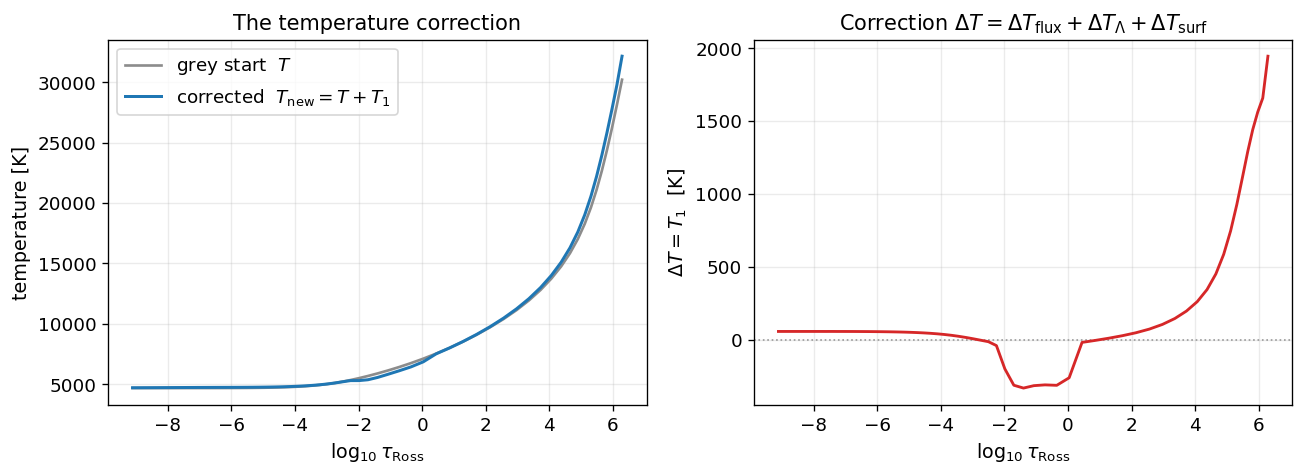

correction range: -332 K (surface) to +1945 K (deep)


In [32]:
# corrected temperature on the SAME tau_Ross grid as the correction (so the
# left-panel gap equals the right-panel curve, depth for depth)
tnew_plot = tnew

fig, ax = plt.subplots(1, 2, figsize=(11, 4.1))
ax[0].plot(np.log10(tauros), T,         color="0.55", lw=1.6, label="grey start  $T$")
ax[0].plot(np.log10(tauros), tnew_plot, color="C0",   lw=1.8, label=r"corrected  $T_{\rm new}=T+T_1$")
ax[0].set_xlabel(r"$\log_{10}\tau_{\rm Ross}$"); ax[0].set_ylabel("temperature [K]")
ax[0].set_title("The temperature correction"); ax[0].legend(loc="upper left")

ax[1].axhline(0.0, color="0.6", ls=":", lw=1.0)
ax[1].plot(np.log10(tauros), t1, color="C3", lw=1.7)
ax[1].set_xlabel(r"$\log_{10}\tau_{\rm Ross}$"); ax[1].set_ylabel(r"$\Delta T = T_1$  [K]")
ax[1].set_title(r"Correction $\Delta T = \Delta T_{\rm flux}+\Delta T_\Lambda+\Delta T_{\rm surf}$")
fig.tight_layout(); plt.show()
print(f"correction range: {t1.min():+.0f} K (surface) to {t1.max():+.0f} K (deep)")

## What comes next: convergence, convection, and line blanketing

We built **one** correction step. A real ATLAS model **iterates** it: recompute the equation of state, opacities, Rosseland mean, and fluxes on the corrected temperature, correct again, and repeat until the flux is constant to a part in $10^4$ and the temperature stops moving — typically a few dozen iterations. The acceleration/damping logic we skipped (it compares each layer's correction to the previous iteration's, growing it when the sign is steady and halving it on a sign flip) is what makes that convergence fast and stable.

Two physical ingredients we deliberately left out enter next. **Convection**: below the photosphere of a cool star, part of the energy is carried by rising and falling gas rather than radiation, and the correction must account for the convective flux (the zeroed `flxcnv` arrays in our code are where it plugs in). **Line blanketing**: the real opacity includes millions of spectral lines, which trap radiation and reshape the temperature structure — switching them on means the frequency sweep carries line opacity (Lectures 4–6) alongside the continuum, but the correction machinery is unchanged.

A practical note on starting points. We seeded the iteration with the deterministic **grey start** of Lecture 9, which is why this book stays reproducible with only NumPy. Production pipelines often warm-start instead from a neural-network *emulator* that predicts a near-converged structure directly from $(T_{\rm eff}, \log g, [\mathrm{M/H}])$, cutting the iteration count — but that emulator is an *optional* accelerator, not part of the physics. For the class of 1D LTE ATLAS models considered here the grey start is a robust deterministic seed; it is what the whole correction loop is built on.

With this lecture the loop the course has traced is complete in principle: **parameters $\to$ hydrostatic structure (Lecture 9) $\to$ radiative-equilibrium correction (this lecture) $\to$, iterated, a self-consistent atmosphere $\to$ the spectrum (Lectures 1–8)**. A star's few numbers become its full structure and its emergent spectrum, from the standard 1D LTE model-atmosphere assumptions and to the pipeline's roundoff floor.

## Synthesis

The grey starting atmosphere from Lecture 9 is hydrostatically balanced but **not** in radiative equilibrium: its radiative flux is not constant with depth, because the grey temperature law ignores the wavelength dependence of the opacity. We measured that flux defect directly — tens of percent at the surface, drifting with depth — and then built ATLAS's `TCORR` engine to remove it. The machinery is: compute the **Rosseland mean** $\kappa_{\rm Ross}$ (a harmonic, $\partial B_\nu/\partial T$-weighted frequency average motivated by the diffusion-limit flux) and the real optical-depth scale $\tau_{\rm Ross}$; sweep the continuum frequencies, running **JOSH** (Lecture 8) at each to get the per-frequency flux $H_\nu$ and moment $J_\nu-S_\nu$, and accumulate four depth integrals; assemble the correction $T_1 = \Delta T_{\rm flux} + \Delta T_\Lambda + \Delta T_{\rm surf}$ from the Avrett–Krook flux term (deep layers), the local-$\Lambda$ term (thin surface), and the surface-boundary term (emergent flux); accumulate the radiation-pressure moment $P_{\rm rad} = \frac{4\pi}{c}\int\!\!\int\kappa_\nu H_\nu\,d\nu\,d(\rho x)$ (`RADIAP`) from the very same per-frequency flux; re-integrate hydrostatic equilibrium with the real Rosseland opacity and that computed $P_{\rm rad}$ for the density correction $\Delta\rho x$; and remap onto the standard grid to close the iteration. The corrected temperature *and* the corrected column mass both match the production code to the pipeline's $\sim10^{-9}$ roundoff floor.

## Summary

- **Radiative equilibrium** requires the radiative flux to be constant with depth, equal to $H = \sigma T_{\rm eff}^4/(4\pi)$. The grey atmosphere violates this; the temperature correction fixes it.
- The **Rosseland mean** is the *harmonic* average $1/\kappa_{\rm Ross} = \int(1/\kappa_\nu)(\partial B_\nu/\partial T)\,d\nu \big/ \int(\partial B_\nu/\partial T)\,d\nu$, with $\int(\partial B_\nu/\partial T)\,d\nu = (4\sigma/\pi)T^3$; the reciprocal weighting lets the transparent windows carry the flux, as the diffusion limit demands. Integrating $\kappa_{\rm Ross}$ against the column mass gives the real $\tau_{\rm Ross}$ scale.
- **JOSH** (Lecture 8) supplies the per-frequency depth profiles $H_\nu(\tau)$ and $(J_\nu-S_\nu)(\tau)$; four frequency integrals (`flxrad`, `rjmins`, `rdabh`, `rdiagj`) feed the correction, and a fifth — $\int\kappa_\nu H_\nu\,d\nu$ — is the **`RADIAP` radiation-pressure moment** that, integrated down the column, gives $P_{\rm rad}$. The float32 $\Lambda$-iteration inside JOSH leaves a $\sim10^{-6}$–$10^{-7}$ floor on those frequency integrals.
- The correction is **three terms**: the **Avrett–Krook** flux term enforces flux constancy in the deep layers (via a clamped optical-depth shift); the **local-$\Lambda$** term corrects the thin surface using the net heating divided by the $\Lambda$-diagonal; the **surface-boundary** term fixes the emergent flux. A **monotonicity** clamp keeps $T$ increasing with depth.
- The **density correction** $\Delta\rho x$ comes from re-running the Lecture-9 hydrostatic integrator on $T$ and $T+T_1$ — now using the **real** Rosseland opacity via a `ROSSTAB` table and the **computed** radiation pressure $P_{\rm rad}$ (subtracted to recover the gas pressure) — and taking the fractional pressure change. A final **`map1` remap** onto the standard grid closes the iteration.
- One step reproduces the production code's corrected **temperature and column mass to the pipeline's $\sim10^{-9}$ roundoff floor**; iterating it drives a real model to radiative equilibrium.

## Practice exercises

**1. Why harmonic, not arithmetic.** Replace the Rosseland accumulator's $1/\kappa_\nu$ weighting with a straight $\kappa_\nu$ weighting (an arithmetic mean) and recompute $\kappa_{\rm Ross}$ and $\tau_{\rm Ross}$. How does the optical-depth scale change, especially deep in the atmosphere? Explain physically why the *transparent* windows must dominate the flux in the diffusion limit, and why an arithmetic mean (dominated by the opaque frequency regions — lines in the full problem, continuum opacity peaks in this simplified run) gets the deep structure badly wrong.

**2. Each term's territory.** Plot $\Delta T_{\rm flux}$, $\Delta T_\Lambda$, and $\Delta T_{\rm surf}$ separately versus $\log\tau_{\rm Ross}$. Confirm that the local-$\Lambda$ term lives only at $\tau<1$, the surface term is a near-uniform offset, and the Avrett–Krook term carries the deep layers. At roughly what optical depth does the dominant term hand off from local-$\Lambda$ to Avrett–Krook?

**3. The $\pm\tau/3$ clamp.** Remove the `np.clip(dtau, -tauros/3, tauros/3)` stability clamp on the Avrett–Krook optical-depth shift and recompute $T_1$. Which layers change, and by how much? Explain why an *unclamped* first step from a grey start can overshoot, and why clamping the step (rather than the temperature) is the right place to impose stability.

**4. Toward convergence.** Take the corrected $T_{\rm out}$ as a new starting temperature and re-run the whole notebook's pipeline a second time (continuum opacities held fixed, as a simplification). Does the flux-error curve flatten? Plot the surface and deep flux errors after iteration 1 and iteration 2. (For a true convergence you would also recompute the opacities on the new $T$ — explain why that coupling is essential and why holding them fixed under-corrects.)

**5. Where the float32 floor lives.** The corrected temperature and column mass both match to $\sim10^{-9}$, yet the frequency-integrated accumulators (`rjmins`, `flxrad`, `rdabh`) printed during the sweep sit at $\sim10^{-6}$–$10^{-7}$. That floor is the **float32** $\Lambda$-iteration inside `josh_profiles` — the one single-precision step in the pipeline — jittering $\kappa_\nu$ and $H_\nu$ at the last bit. Confirm it by re-running JOSH's inner sweep in float64 (cast `xs` and the operands to `np.float64`) and watching those accumulators drop toward $\sim10^{-12}$. Then explain the apparent paradox: why do the *final* corrected $T$ and $\rho x$ land at $\sim10^{-9}$ — better than the accumulators they are built from? (Hint: the correction is a smooth, near-linear functional of those integrals, and the same float32 jitter sits in both our path and the reference path, so much of it cancels in the relative comparison.)

**6. The radiation-pressure moment.** The notebook computes $P_{\rm rad}$ from the `RADIAP` integrand $\int\kappa_\nu H_\nu\,d\nu$ and prints it against the reference to the pipeline's $\sim10^{-9}$ roundoff floor. Remove the flux-limit safeguard (the `accrad[over] *= flux/flxrad[over]` cap) and recompute $P_{\rm rad}$. Which layers change, and why are they exactly the surface layers where the un-converged flux $H(\tau)$ overshoots the target $H$? Explain physically why an over-target flux would otherwise push an unphysically large radiative acceleration into the hydrostatic balance.

## Further reading

- **Avrett, E. H. & Krook, M. (1963). *The Temperature Distribution in a Stellar Atmosphere*, ApJ 137, 874.** The flux-constancy temperature correction that is the workhorse term $\Delta T_{\rm flux}$ here.
- **Mihalas, D. (1978). *Stellar Atmospheres*, 2nd ed., Freeman.** Chapter 7 on radiative equilibrium and temperature-correction procedures (Avrett–Krook, Unsöld–Lucy, and the $\Lambda$-iteration), and Chapter 3 on the Rosseland mean.
- **Hubeny, I. & Mihalas, D. (2014). *Theory of Stellar Atmospheres*, Princeton.** Chapters 17–18 on the numerical construction of model atmospheres, radiative-equilibrium constraints, and convergence acceleration.
- **Gray, D. F. (2005). *The Observation and Analysis of Stellar Photospheres*, 3rd ed., Cambridge University Press.** Chapter 9 on the Rosseland mean and the grey-to-non-grey temperature structure.
- **Kurucz, R. L. (1970). *ATLAS: A Computer Program for Calculating Model Stellar Atmospheres*, SAO Special Report 309**, and **Castelli, F. & Kurucz, R. L. (2003), *Modelling of Stellar Atmospheres*, IAU Symp. 210, poster A20 (arXiv:astro-ph/0405087).** The ATLAS temperature correction (`TCORR`), Rosseland-mean (`ROSS`), and `ROSSTAB`/`TTAUP` routines reproduced in this lecture.
- **Kim, E. M. & Ting, Y.-S. (2026). [*pykurucz*](https://arxiv.org/abs/2603.11693).** The implementation our reference correction is computed with.